# Shock tubes — the complete shared algorithm comparison

**Ehsan Roohi · CFD II · 2026 Python edition**

A separate notebook for the same numerical components used in the modern cone project:
**15 shared Euler fluxes × 20 FV reconstructions**, standalone JST, and DG degrees 0/1/2 with every shared flux.

Use **Runtime → Run all** to display actual recorded runs, the exact solution, physical properties,
mesh-error convergence, the full 300-combination Sod matrix, positivity/conservation histories and stress-case failures.
The complete study contains **592 recorded runs**. Results are displayed before optional fresh simulation.
An additional **75-run local-refinement study** compares every shared pointwise flux on uniform 80/160/320/640 grids and a dynamically refined leaf mesh.
This notebook tests inviscid planar Euler waves; it does not test cone geometry or physical viscosity.

[Algorithm/source audit](https://github.com/Ehsan-Roohi/Ehsan-Roohi/blob/main/courses/cfd-2/modern-python/conical/ADDITIONAL_METHODS.md) · [Report](https://github.com/Ehsan-Roohi/Ehsan-Roohi/blob/main/courses/cfd-2/modern-python/shock-tube/RESULTS.md) · [Shared source](https://github.com/Ehsan-Roohi/Ehsan-Roohi/blob/main/courses/cfd-2/modern-python/conical/shock_suite.py)


In [1]:
# @title Start the shock-tube workspace {display-mode: "form"}
import io,sys,json,hashlib,zipfile,subprocess,importlib.util
from pathlib import Path
from urllib.request import urlopen
missing=[p for p in ("numpy","matplotlib") if importlib.util.find_spec(p) is None]
if missing: subprocess.check_call([sys.executable,"-m","pip","install",*missing])
RUNTIME_URL='https://raw.githubusercontent.com/Ehsan-Roohi/Ehsan-Roohi/main/courses/cfd-2/downloads/shocktube-colab-runtime-dab1b3511376.zip'
RUNTIME_SHA256='dab1b351137643d43f02384a4faf1e76b2806fae2a927873f5de894671d3e7a0'
data=urlopen(RUNTIME_URL,timeout=90).read()
assert hashlib.sha256(data).hexdigest()==RUNTIME_SHA256
WORK=(Path("/content") if Path("/content").exists() else Path.cwd())/"shocktube-modern"
WORK.mkdir(parents=True,exist_ok=True)
with zipfile.ZipFile(io.BytesIO(data)) as z:
    for name in z.namelist():
        p=(WORK/name).resolve()
        if not p.is_relative_to(WORK.resolve()):raise ValueError("Invalid archive path")
        p.parent.mkdir(parents=True,exist_ok=True);p.write_bytes(z.read(name))
sys.path.insert(0,str(WORK))
from shock_dashboard import load,select,show_table,cards,properties,matrix,convergence,histories
from shock_suite import run_case,CASES,RECONSTRUCTIONS,FLUXES
from amr_dashboard import load_amr,show_amr_table,profiles as amr_profiles,mesh_evolution as amr_mesh,all_flux_cards as amr_cards,accuracy as amr_accuracy,widths as amr_widths
from shock_amr import run_case as run_amr
study=load()
print("Ready:",len(study),"recorded runs; 15 shared fluxes, 20 reconstructions, standalone JST and DG.")


Ready: 592 recorded runs; 15 shared fluxes, 20 reconstructions, standalone JST and DG.


## 1. Every flux has a visible result

Common Sod case, 80 cells, CWENO3, SSPRK3, CFL 0.25. JST is a separate central stencil using cell means.
Exact cell-average references are compared with conserved cell means. The HLL/`hlle` key uses Davis acoustic bounds.
The same names in different repositories can hide different wave-speed or dissipation choices; see the algorithm audit.


Flux,Reconstruction,Cells,Actual time,Status,Density L1,Conservation defect
AUSM,cweno3,80,0.2,Completed / integrity passed,0.0089123,2.13e-16
AUSM+,cweno3,80,0.2,Completed / integrity passed,0.0086264,2.58e-16
AUSM+-up,cweno3,80,0.2,Completed / integrity passed,0.012942,2.10e-16
AUSM+-up2,cweno3,80,0.2,Completed / integrity passed,0.012233,4.90e-16
EC + LF,cweno3,80,0.2,Completed / integrity passed,0.010906,2.37e-16
Global LF,cweno3,80,0.2,Completed / integrity passed,0.011665,5.86e-16
Godunov,cweno3,80,0.2,Completed / integrity passed,0.0083767,3.65e-16
HLLC,cweno3,80,0.2,Completed / integrity passed,0.0088196,2.50e-16
HLL / Davis,cweno3,80,0.2,Completed / integrity passed,0.0090009,2.33e-16
Roe,cweno3,80,0.2,Completed / integrity passed,0.0085319,6.84e-16


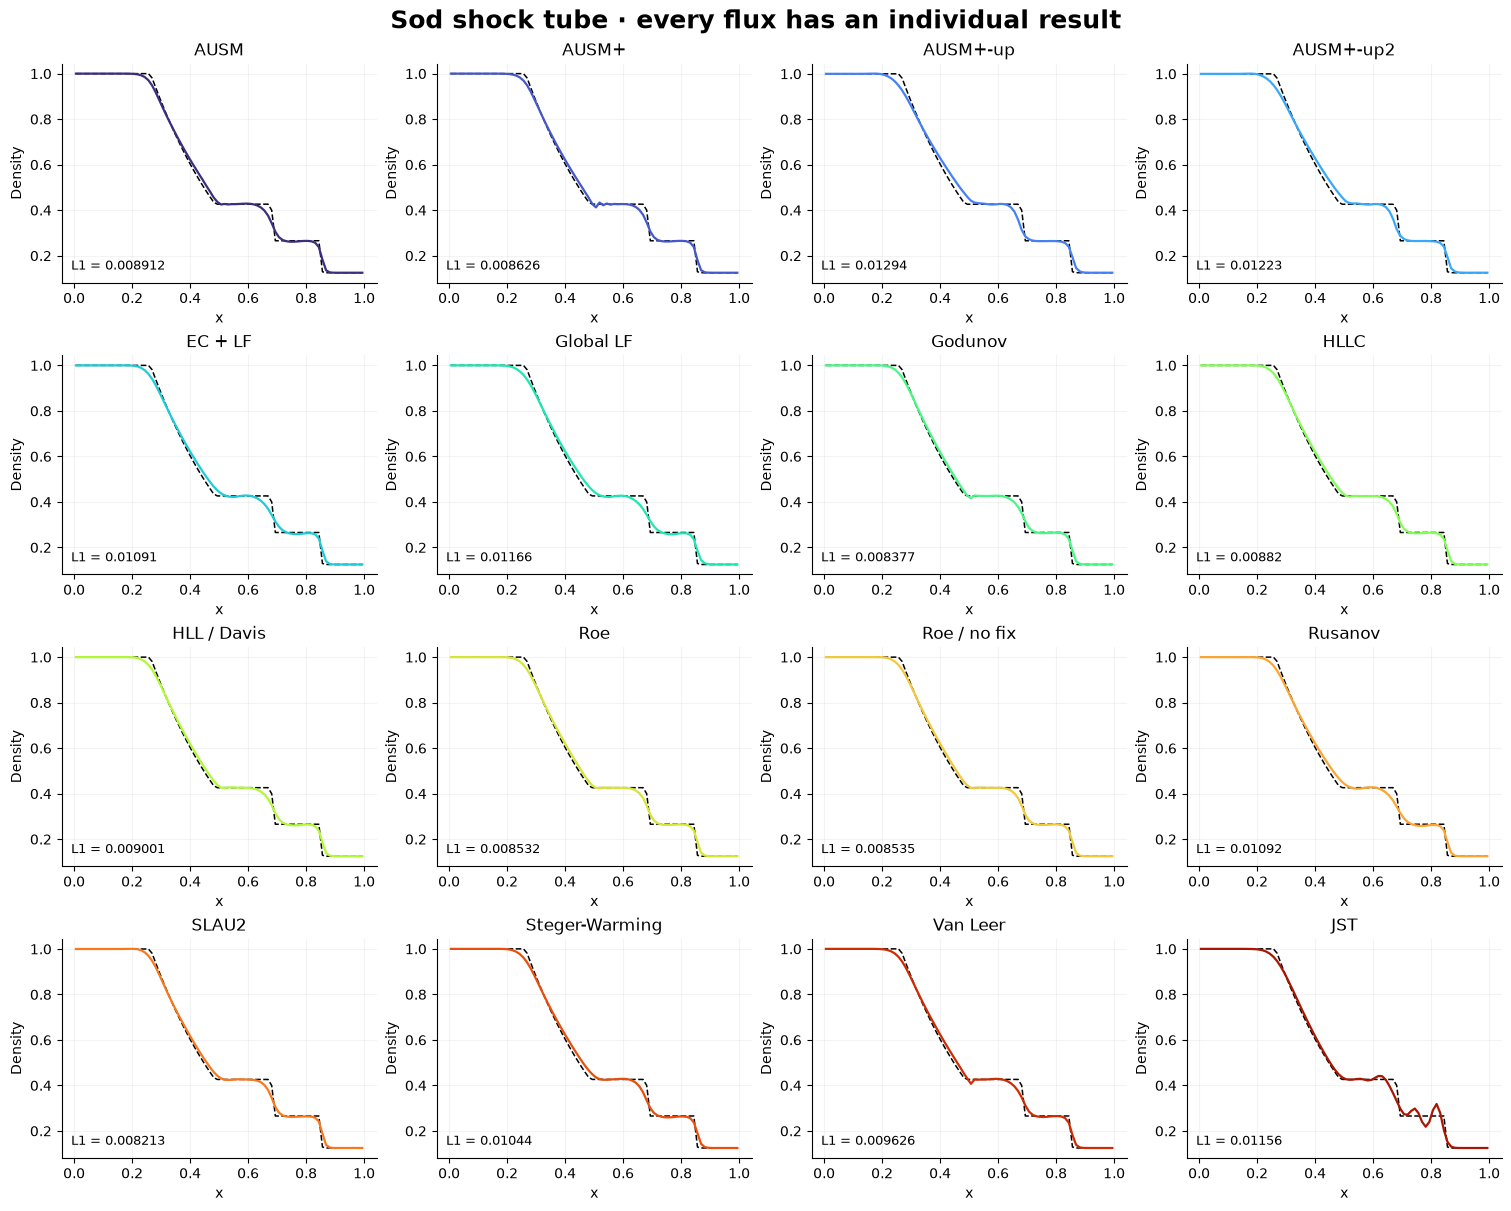

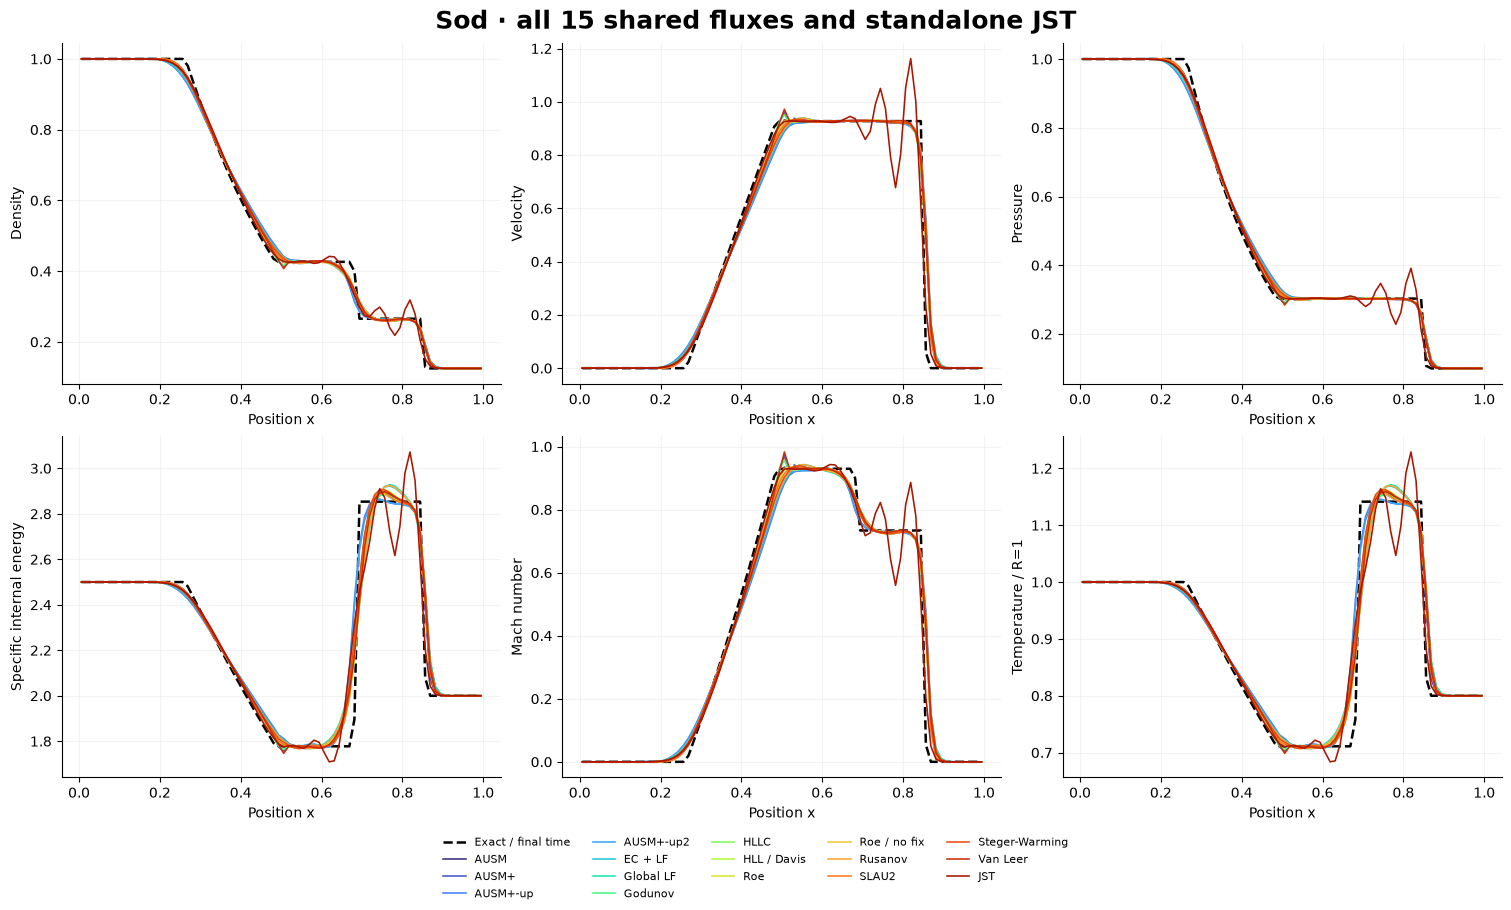

In [2]:
baseline=select(study,reconstruction="cweno3")+select(study,flux="jst",reconstruction="first")
show_table(baseline)
cards(baseline)
properties(baseline,"sod-all-flux-properties","Sod · all 15 shared fluxes and standalone JST")


## 2. Full flux × reconstruction comparison

All 300 combinations are actually executed. The heatmap reports density L1 error, not a count of different flux models.
The full table is collapsible. Completion and conservation are necessary integrity checks, not universal accuracy certificates.


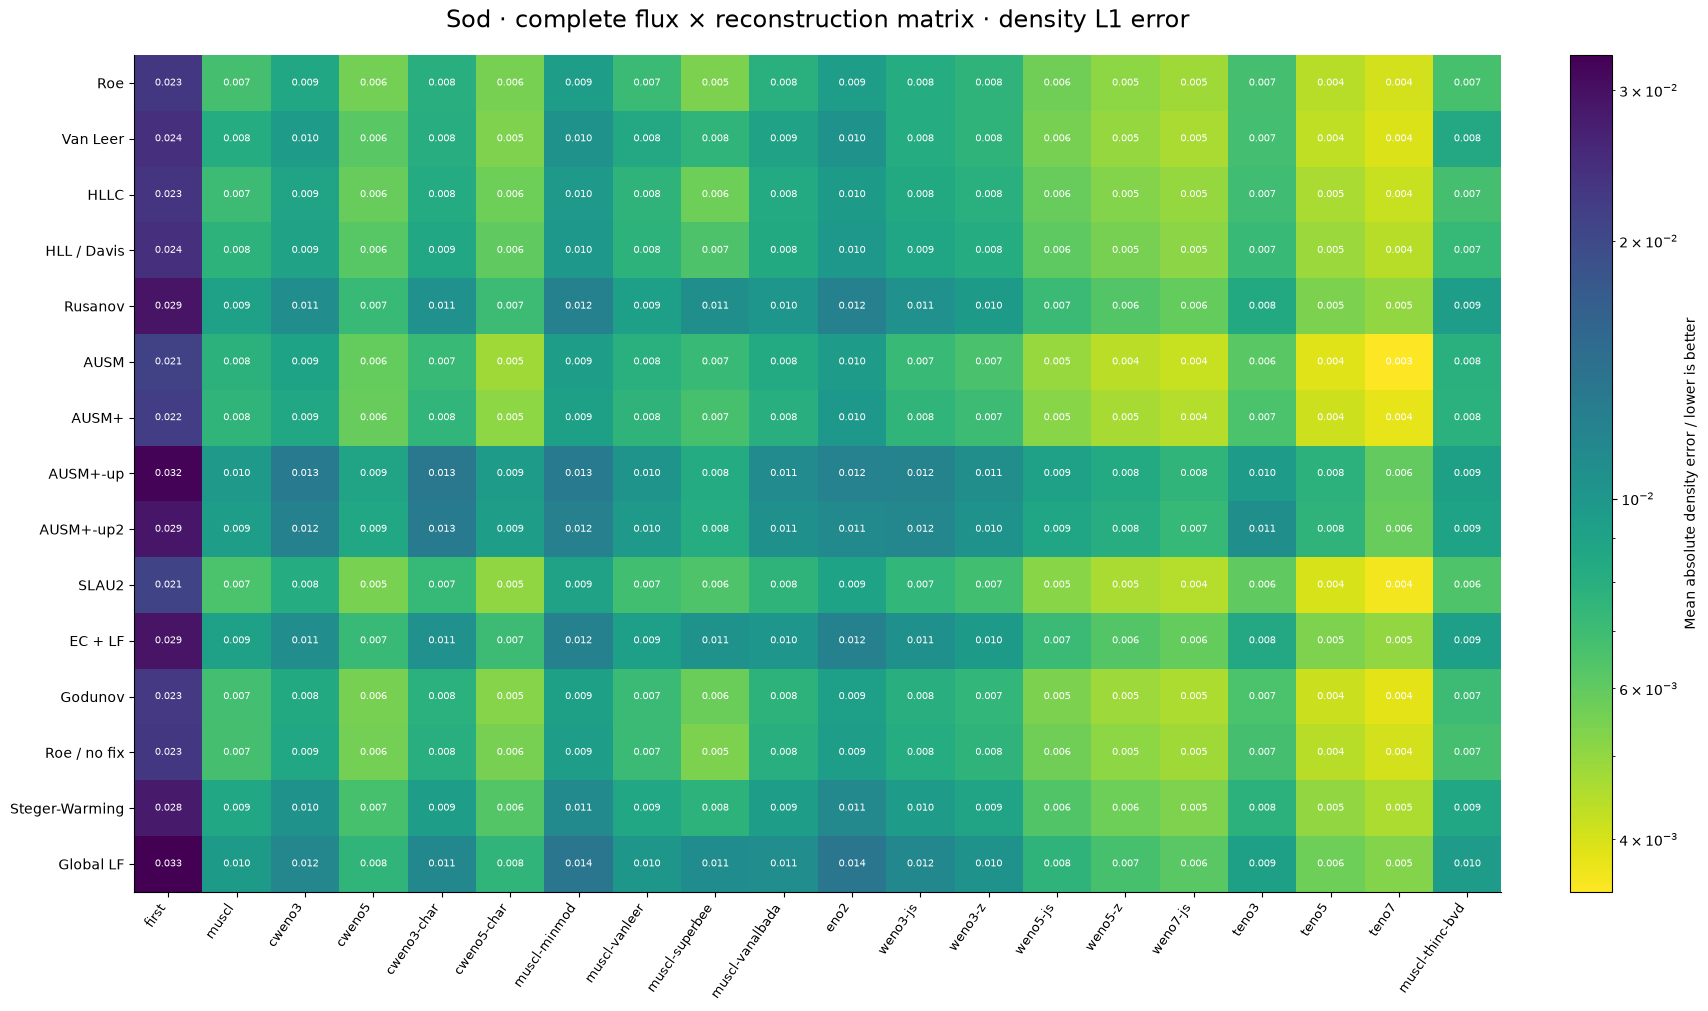

Flux,Reconstruction,Cells,Actual time,Status,Density L1,Conservation defect
AUSM,cweno3-char,80,0.2,Completed / integrity passed,0.0071617,5.67e-16
AUSM,cweno3,80,0.2,Completed / integrity passed,0.0089123,2.13e-16
AUSM,cweno5-char,80,0.2,Completed / integrity passed,0.0048075,2.21e-16
AUSM,cweno5,80,0.2,Completed / integrity passed,0.0059194,2.99e-16
AUSM,eno2,80,0.2,Completed / integrity passed,0.0095111,7.43e-16
AUSM,first,80,0.2,Completed / integrity passed,0.021208,4.63e-16
AUSM,muscl-minmod,80,0.2,Completed / integrity passed,0.0094039,1.83e-16
AUSM,muscl,80,0.2,Completed / integrity passed,0.0077391,4.44e-16
AUSM,muscl-superbee,80,0.2,Completed / integrity passed,0.0072603,2.22e-16
AUSM,muscl-thinc-bvd,80,0.2,Completed / integrity passed,0.0079081,2.22e-16


In [3]:
full_matrix=[r for r in select(study) if r["config"]["flux"]!="jst"]
assert len(full_matrix)==len(FLUXES)*len(RECONSTRUCTIONS)==300
matrix(full_matrix,list(FLUXES),RECONSTRUCTIONS)
show_table(full_matrix,collapsible=True)


## 3. Reconstruction families at fixed HLLC flux

Constant, MC and four additional MUSCL limiters; ENO2; CWENO3/5 in component and characteristic variables;
characteristic WENO-JS/Z3/5 and WENO-JS7; TENO3/5/7; an educational one-stage MUSCL–THINC–BVD variant.
THINC is not a new Riemann solver. TENO3/7 use inverse-smoothness cutoff; these are not adaptive TENO-A/LAD.


Flux,Reconstruction,Cells,Actual time,Status,Density L1,Conservation defect
HLLC,cweno3-char,80,0.2,Completed / integrity passed,0.0082861,1.06e-15
HLLC,cweno3,80,0.2,Completed / integrity passed,0.0088196,2.50e-16
HLLC,cweno5-char,80,0.2,Completed / integrity passed,0.0057191,3.21e-16
HLLC,cweno5,80,0.2,Completed / integrity passed,0.0058635,4.11e-16
HLLC,eno2,80,0.2,Completed / integrity passed,0.0097016,3.03e-16
HLLC,first,80,0.2,Completed / integrity passed,0.023386,1.76e-16
HLLC,muscl-minmod,80,0.2,Completed / integrity passed,0.0097162,3.62e-16
HLLC,muscl,80,0.2,Completed / integrity passed,0.0070229,6.66e-16
HLLC,muscl-superbee,80,0.2,Completed / integrity passed,0.0057229,4.44e-16
HLLC,muscl-thinc-bvd,80,0.2,Completed / integrity passed,0.0067275,2.22e-16


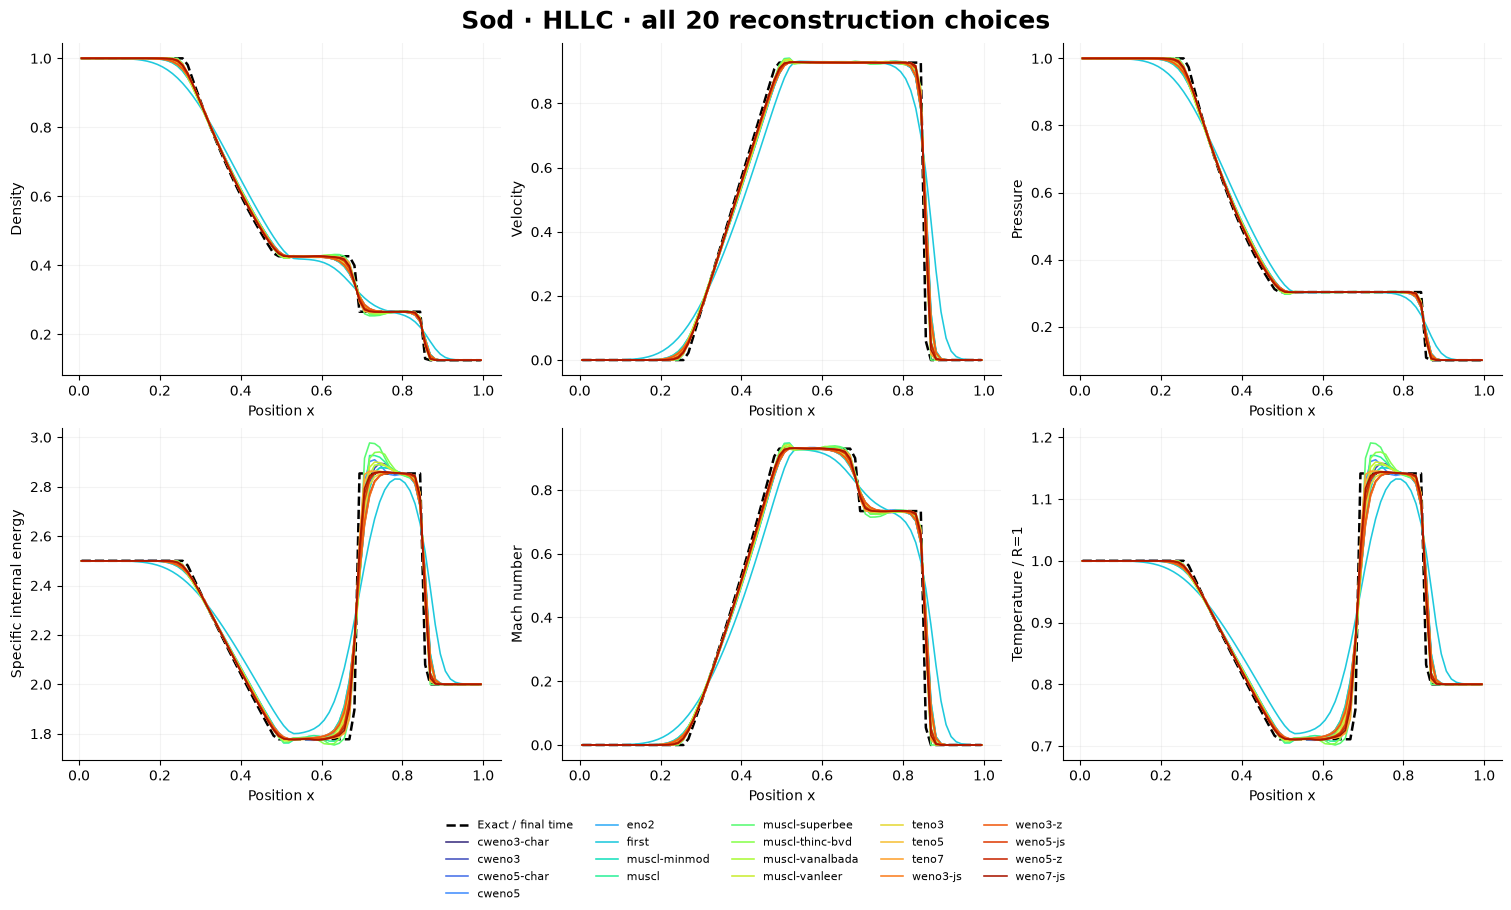

In [4]:
recon=select(study,flux="hllc")
show_table(recon)
properties(recon,"sod-all-reconstruction-properties","Sod · HLLC · all 20 reconstruction choices",by="reconstruction")


## 4. Mesh-error convergence

Three grids: 40, 80, 160 cells/elements. Compare each flux with CWENO3, each FV reconstruction with HLLC,
and all shared DG fluxes at degrees 0/1/2. These are targeted component studies, not three-grid runs of all 300 FV combinations.
Shock/contact discontinuities reduce measured global order; formal smooth order is checked separately.


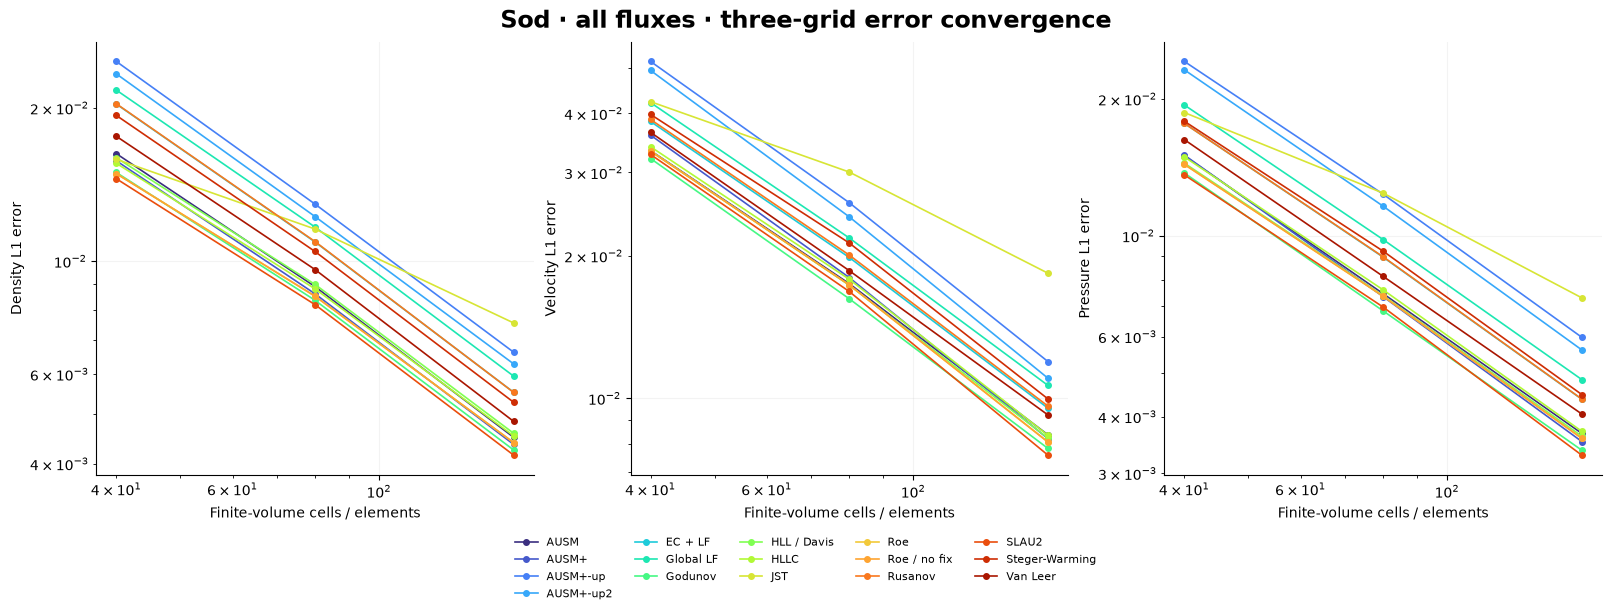

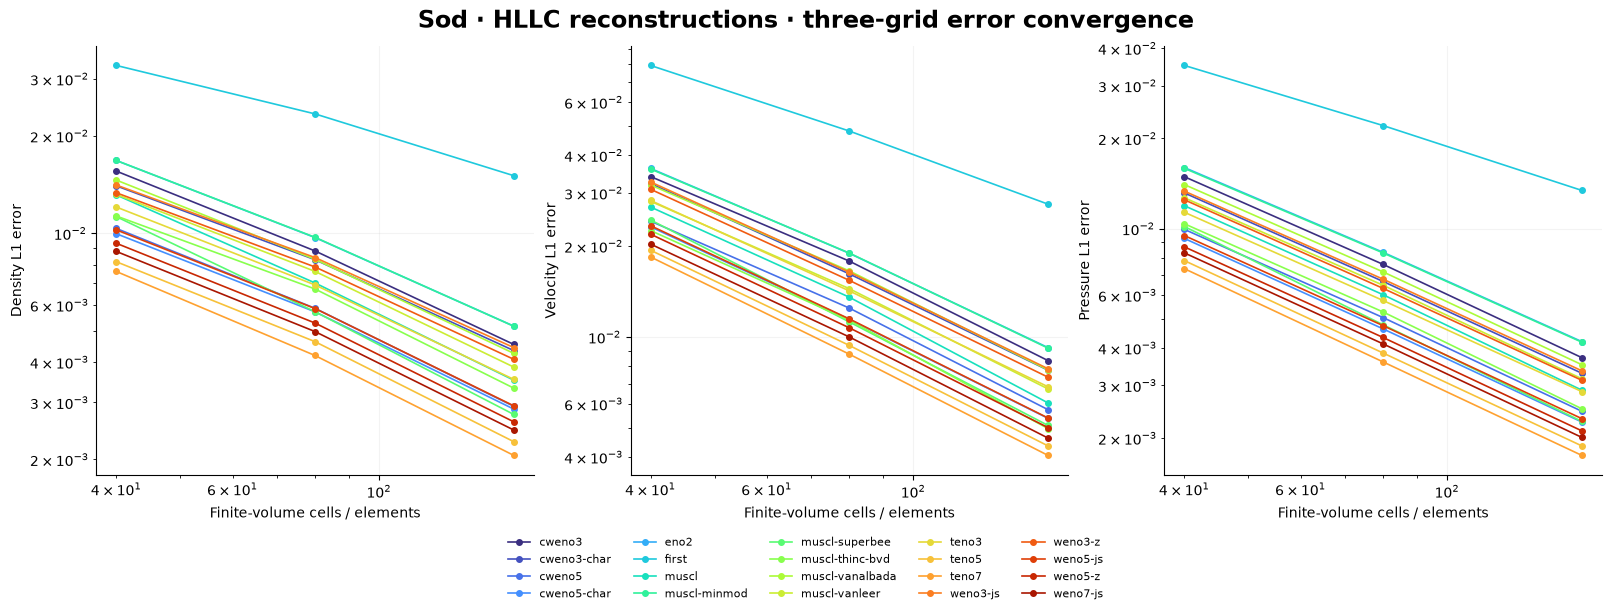

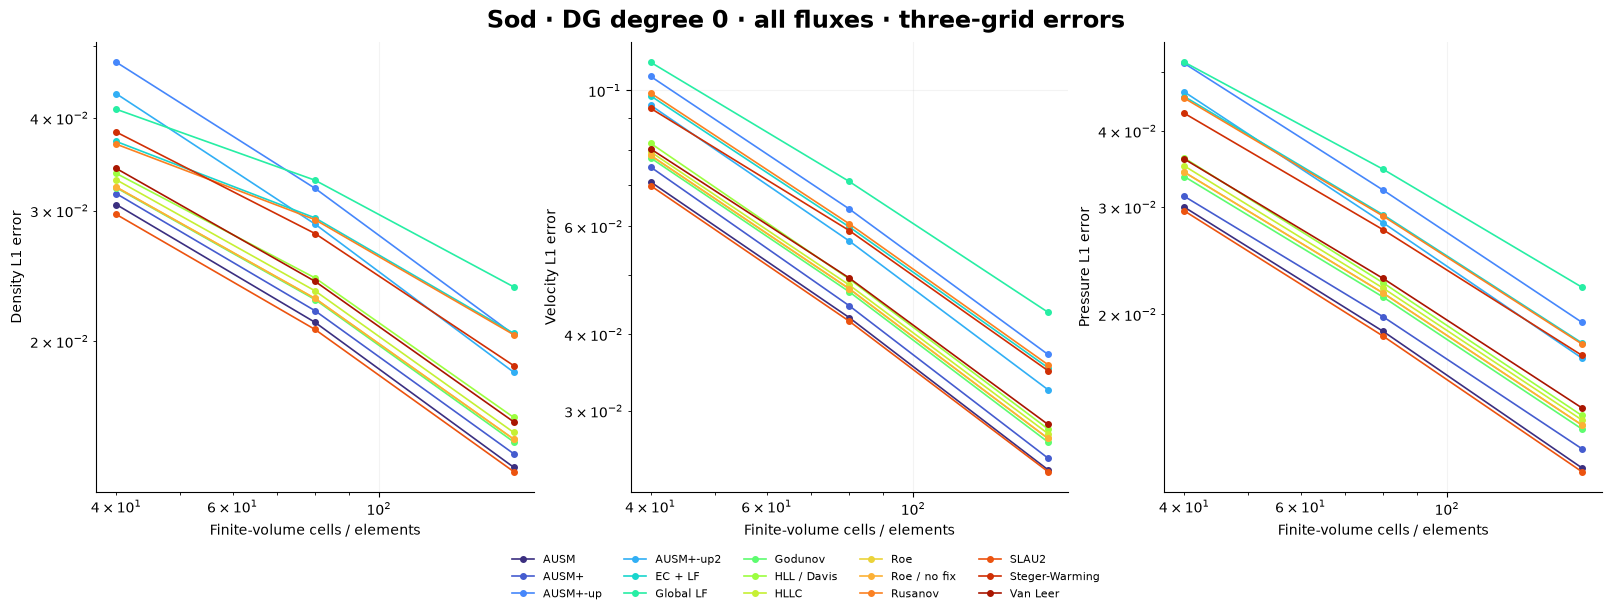

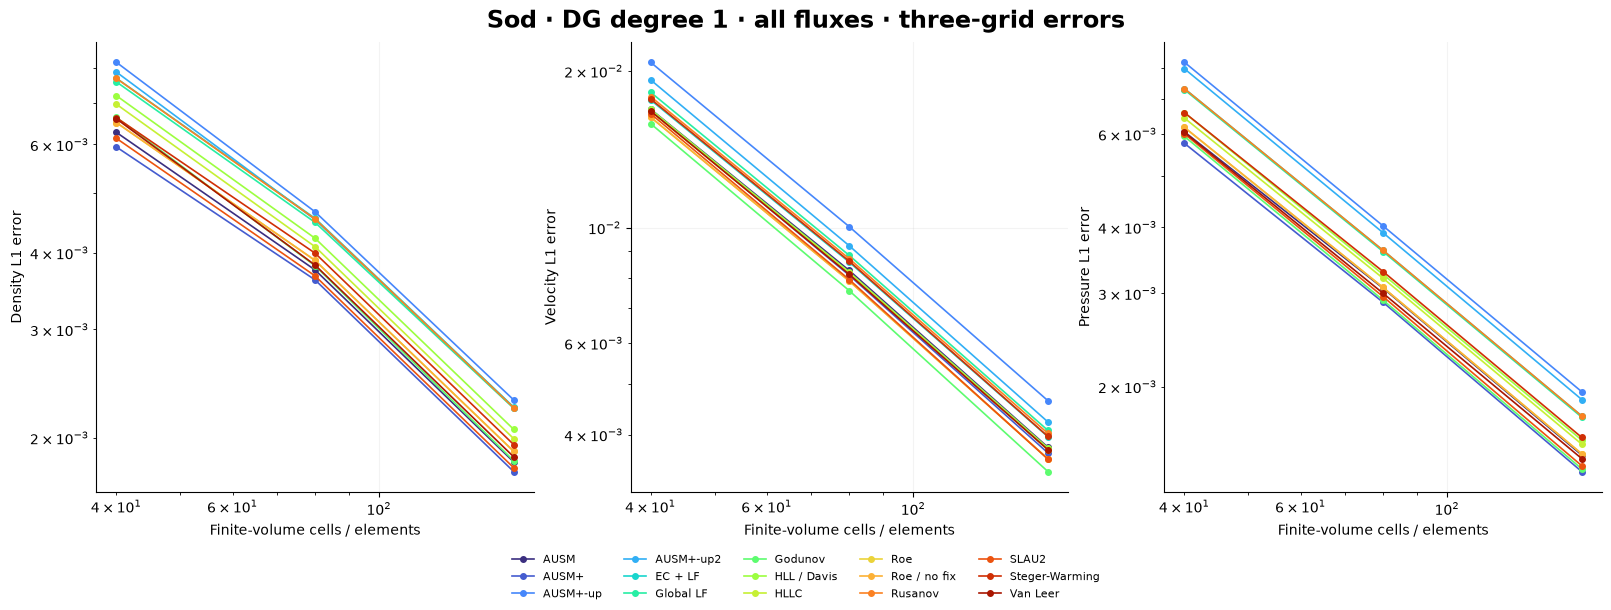

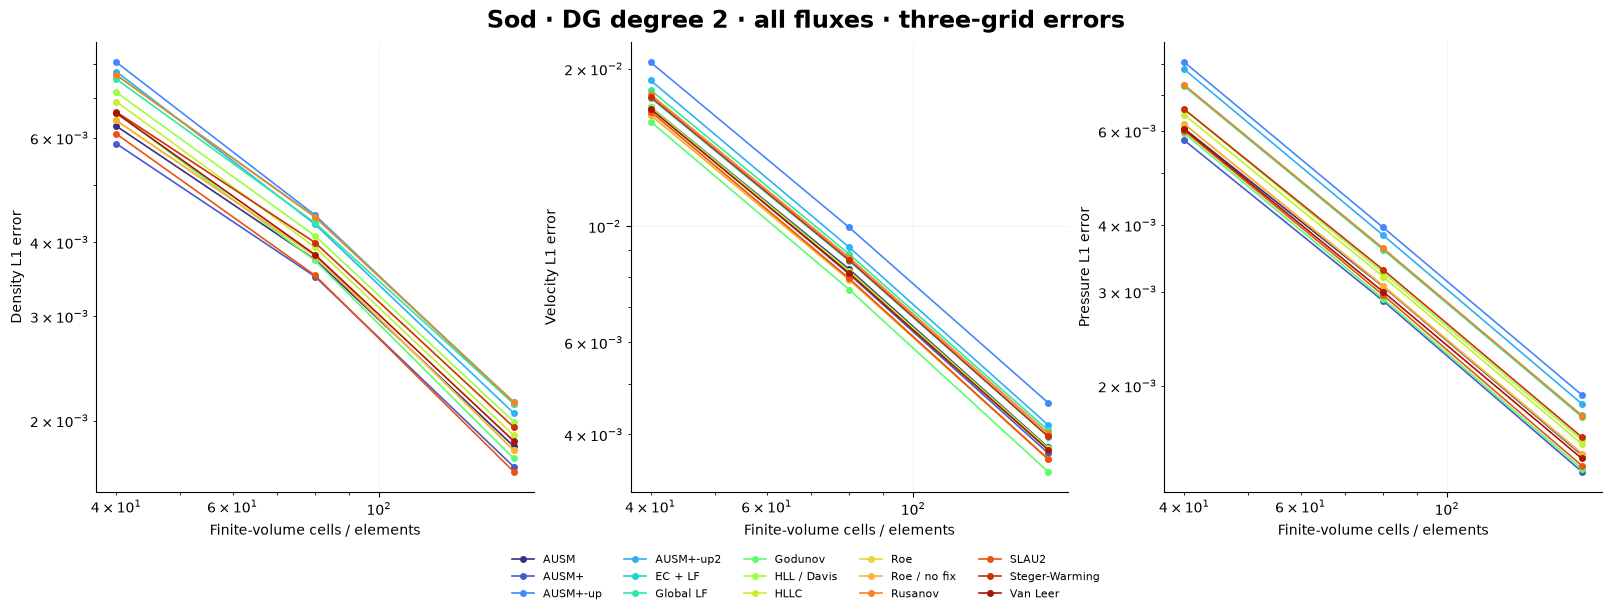

In [5]:
flux_grids=select(study,cells=None,reconstruction="cweno3")+select(study,cells=None,flux="jst",reconstruction="first")
convergence(flux_grids,"flux-grid-convergence","Sod · all fluxes · three-grid error convergence")
recon_grids=select(study,cells=None,flux="hllc")
convergence(recon_grids,"reconstruction-grid-convergence","Sod · HLLC reconstructions · three-grid error convergence",by="reconstruction")
for p in (0,1,2):
    dg_grid=select(study,cells=None,degree=p)
    convergence(dg_grid,f"dg{p}-grid-convergence",f"Sod · DG degree {p} · all fluxes · three-grid errors")


## 5. DG physical profiles and integrity histories

The modal weak form is shared with the cone DG core, with geometric sources removed and outflow boundaries.
Characteristic TVB limiting and sampled positivity scaling are enabled. Degree alone does not guarantee accuracy through a shock.


Flux,Reconstruction,Cells,Actual time,Status,Density L1,Conservation defect
AUSM,DG 0,80,0.2,Completed / integrity passed,0.021208,4.63e-16
AUSM,DG 1,80,0.2,Completed / integrity passed,0.0037507,3.97e-15
AUSM,DG 2,80,0.2,Completed / integrity passed,0.0037398,4.35e-16
AUSM+,DG 0,80,0.2,Completed / integrity passed,0.021986,2.66e-16
AUSM+,DG 1,80,0.2,Completed / integrity passed,0.0036135,4.57e-15
AUSM+,DG 2,80,0.2,Completed / integrity passed,0.0035003,6.35e-16
AUSM+-up,DG 0,80,0.2,Completed / integrity passed,0.032148,3.67e-16
AUSM+-up,DG 1,80,0.2,Completed / integrity passed,0.0046629,8.01e-16
AUSM+-up,DG 2,80,0.2,Completed / integrity passed,0.004445,5.13e-15
AUSM+-up2,DG 0,80,0.2,Completed / integrity passed,0.028773,2.12e-16


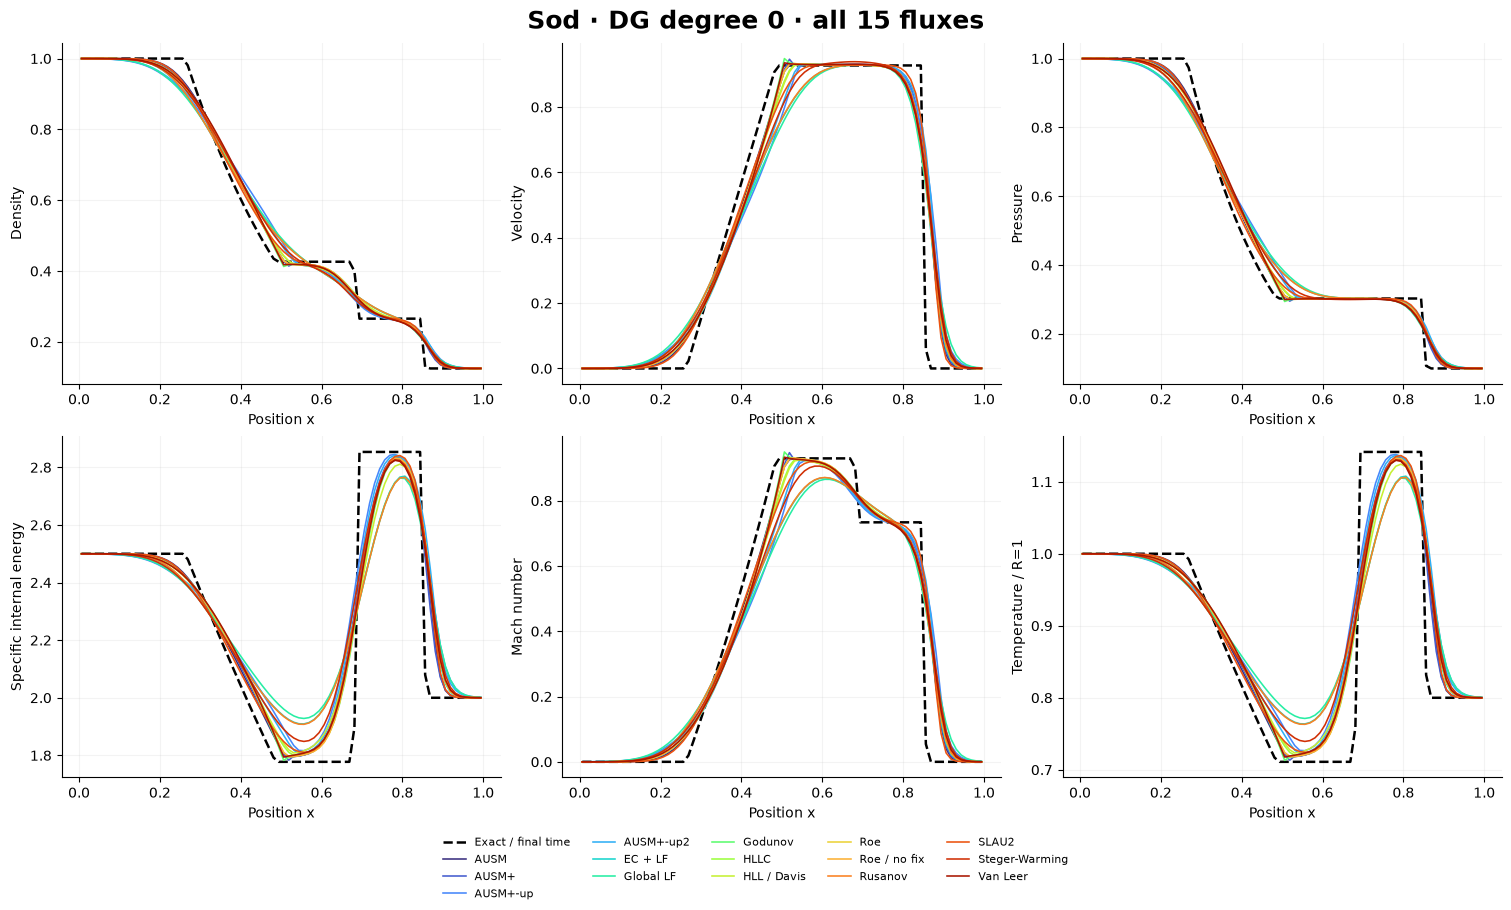

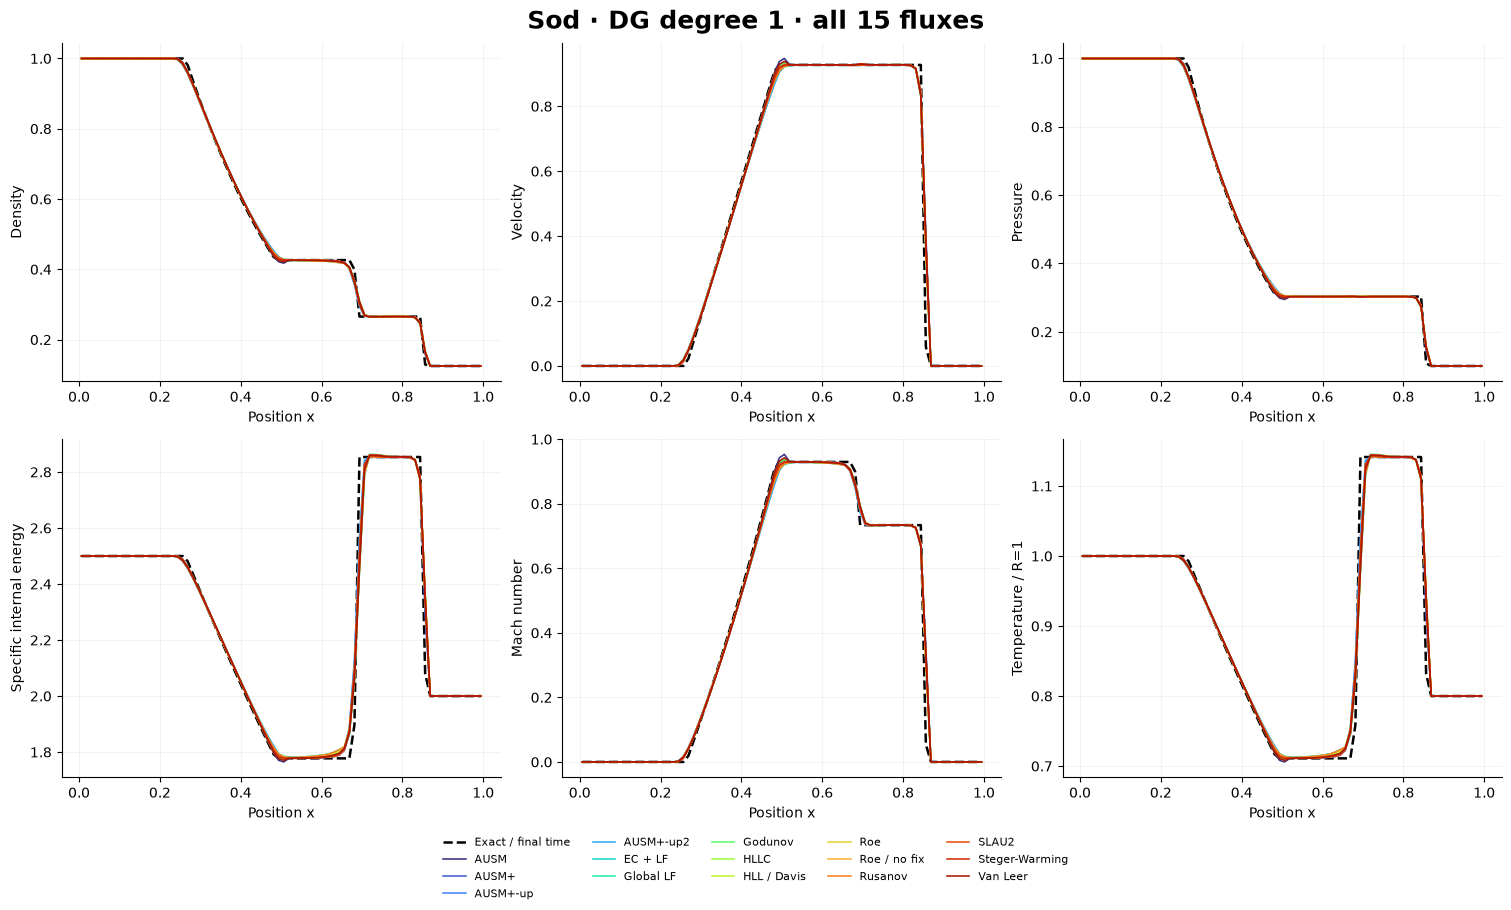

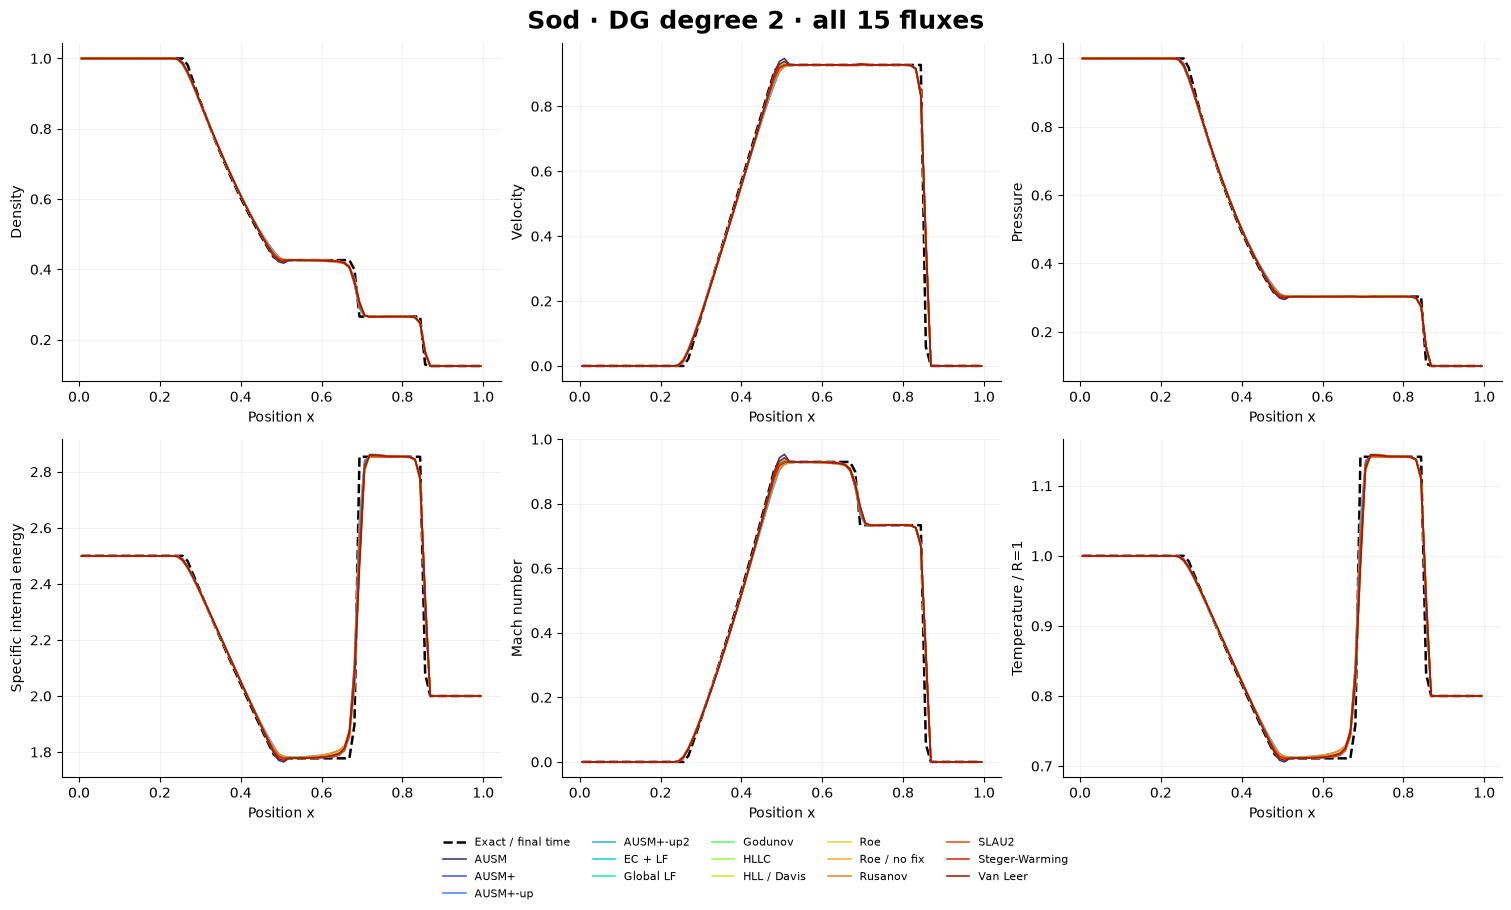

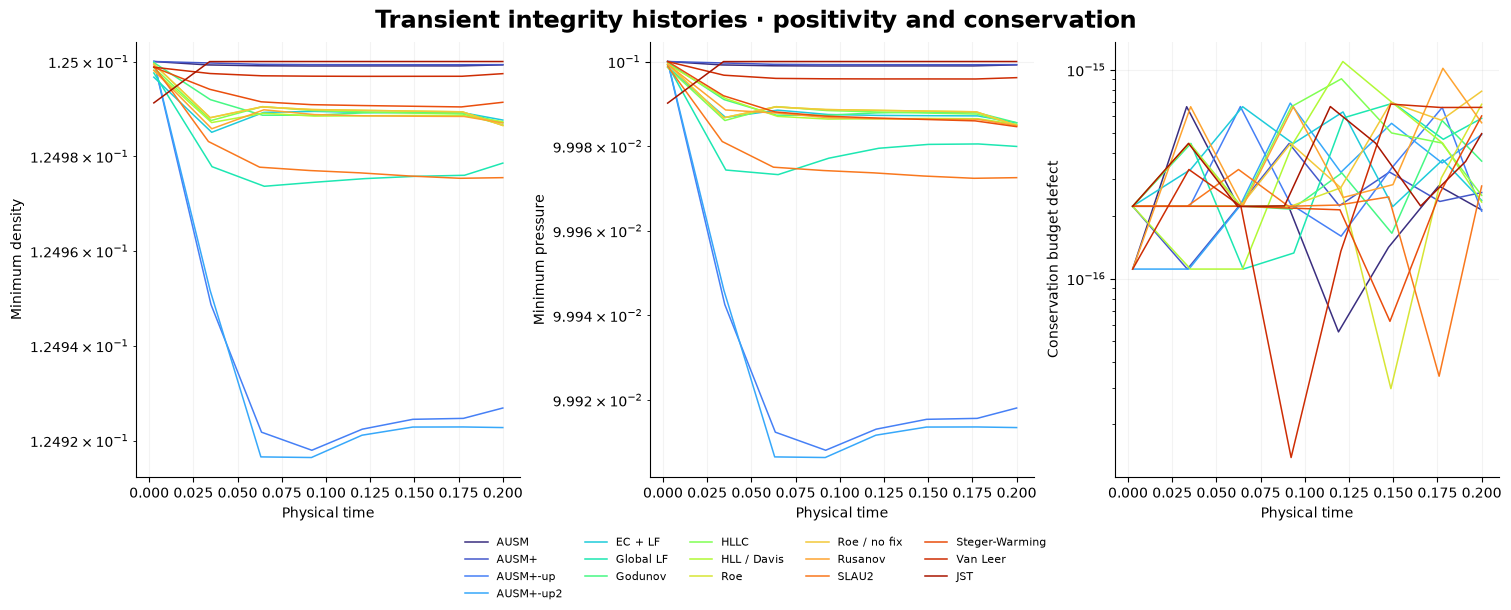

In [6]:
dg_runs=select(study,degree=None)
dg_runs=[r for r in dg_runs if r["config"]["degree"]>=0]
show_table(dg_runs,collapsible=True)
for p in (0,1,2):
    properties(select(study,degree=p),f"dg{p}-properties",f"Sod · DG degree {p} · all 15 fluxes")
histories(baseline)


## 6. Stronger and diagnostic Riemann problems

Lax: stronger waves. Double rarefaction: low density/pressure tests positivity recovery.
Stationary contact: isolates contact diffusion. Every stopped run is labelled with its actual time;
a final-time accuracy error is not assigned to an earlier-time state. Dotted curves show those earlier diagnostic states.
These inviscid cases do not validate a physical-viscosity model.


Flux,Reconstruction,Cells,Actual time,Status,Density L1,Conservation defect
AUSM,cweno3,80,0.14,Completed / integrity passed,0.024199,6.66e-15
AUSM+,cweno3,80,0.14,Completed / integrity passed,0.022948,7.99e-15
AUSM+-up,cweno3,80,0.14,Completed / integrity passed,0.025118,1.07e-14
AUSM+-up2,cweno3,80,0.14,Completed / integrity passed,0.024817,5.77e-15
EC + LF,cweno3,80,0.14,Completed / integrity passed,0.03094,7.55e-15
Global LF,cweno3,80,0.14,Completed / integrity passed,0.036832,8.88e-15
Godunov,cweno3,80,0.14,Completed / integrity passed,0.02464,9.10e-15
HLLC,cweno3,80,0.14,Completed / integrity passed,0.02463,7.11e-15
HLL / Davis,cweno3,80,0.14,Completed / integrity passed,0.026977,8.44e-15
Roe,cweno3,80,0.14,Completed / integrity passed,0.024662,1.07e-14


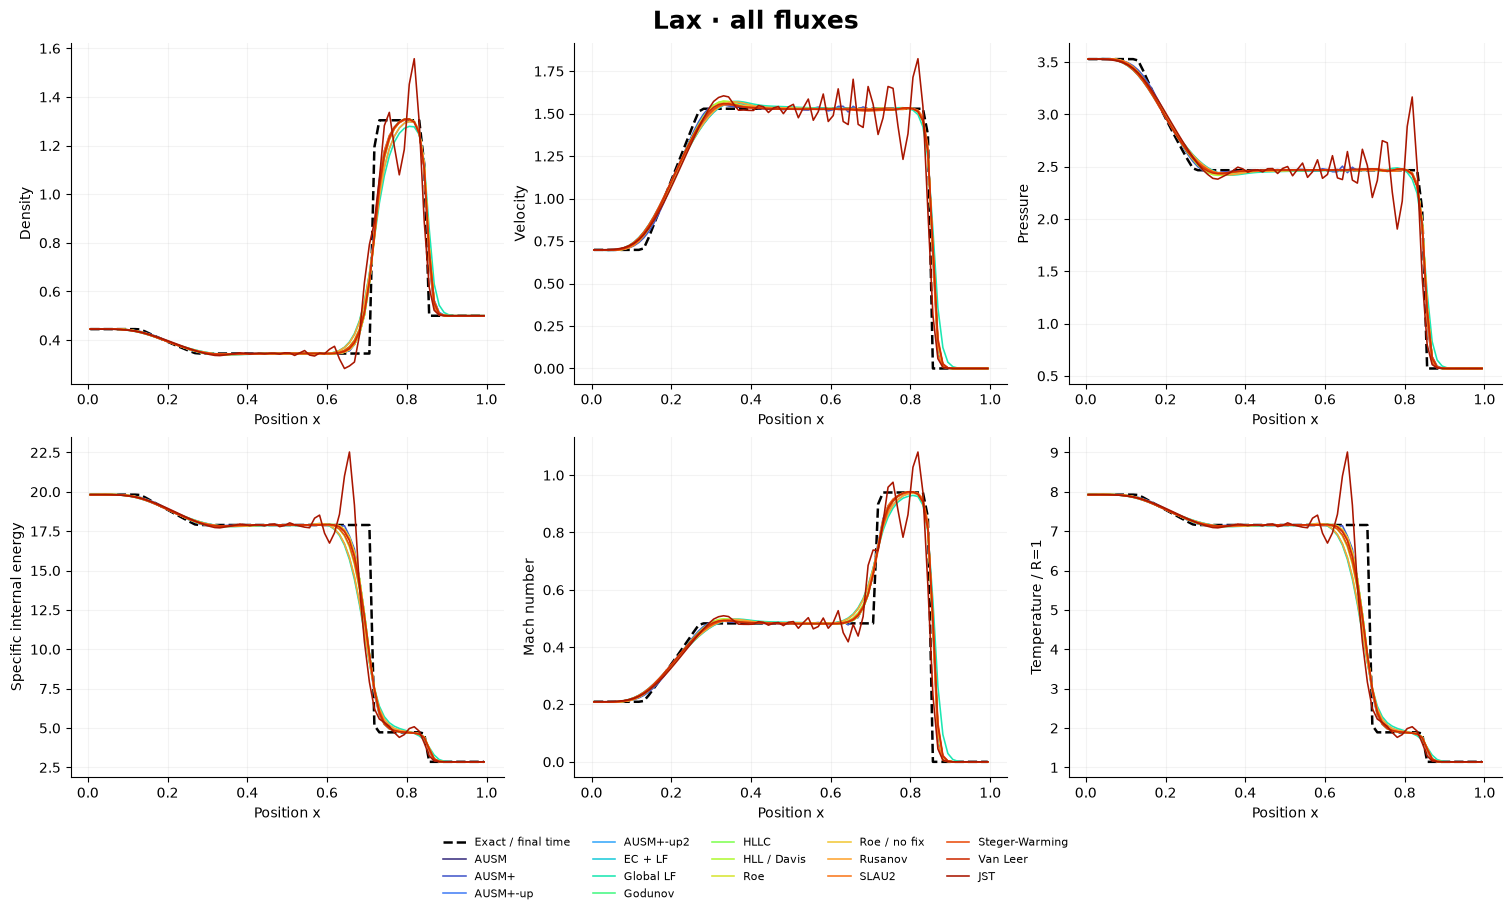

Flux,Reconstruction,Cells,Actual time,Status,Density L1,Conservation defect
AUSM,cweno3,80,0.1,Completed / integrity passed,0.025824,2.22e-16
AUSM+,cweno3,80,0.1,Completed / integrity passed,0.025697,2.22e-16
AUSM+-up,cweno3,80,0.1,Completed / integrity passed,0.025842,8.88e-16
AUSM+-up2,cweno3,80,0.1,Completed / integrity passed,0.02367,6.66e-16
EC + LF,cweno3,80,0.1,Completed / integrity passed,0.019583,4.44e-16
Global LF,cweno3,80,0.1,Completed / integrity passed,0.023526,4.44e-16
Godunov,cweno3,80,0.1,Completed / integrity passed,0.026283,6.66e-16
HLLC,cweno3,80,0.1,Completed / integrity passed,0.023709,8.88e-16
HLL / Davis,cweno3,80,0.1,Completed / integrity passed,0.023708,4.44e-16
Roe,cweno3,80,0.0027425,Positivity recovery exhausted,Not eligible,8.19e-16


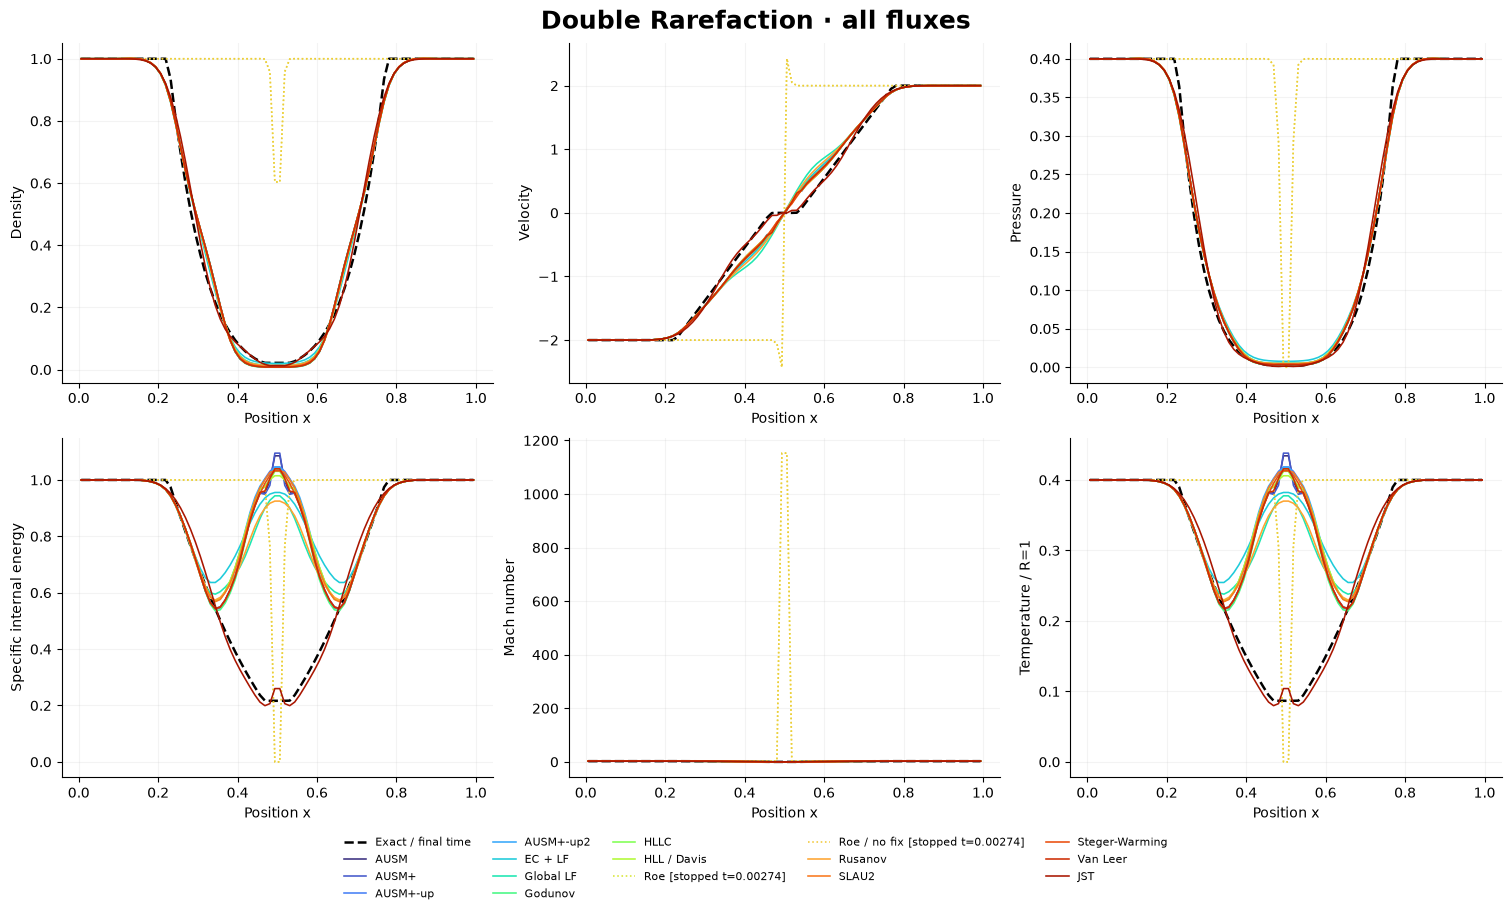

Flux,Reconstruction,Cells,Actual time,Status,Density L1,Conservation defect
AUSM,cweno3,80,0.2,Completed / integrity passed,1.249e-16,0.00e+00
AUSM+,cweno3,80,0.2,Completed / integrity passed,1.249e-16,0.00e+00
AUSM+-up,cweno3,80,0.2,Completed / integrity passed,1.249e-16,0.00e+00
AUSM+-up2,cweno3,80,0.2,Completed / integrity passed,1.249e-16,0.00e+00
EC + LF,cweno3,80,0.2,Completed / integrity passed,0.019863,1.04e-17
Global LF,cweno3,80,0.2,Completed / integrity passed,0.023677,6.26e-18
Godunov,cweno3,80,0.2,Completed / integrity passed,1.249e-16,0.00e+00
HLLC,cweno3,80,0.2,Completed / integrity passed,1.249e-16,0.00e+00
HLL / Davis,cweno3,80,0.2,Completed / integrity passed,0.019863,1.04e-17
Roe,cweno3,80,0.2,Completed / integrity passed,1.249e-16,0.00e+00


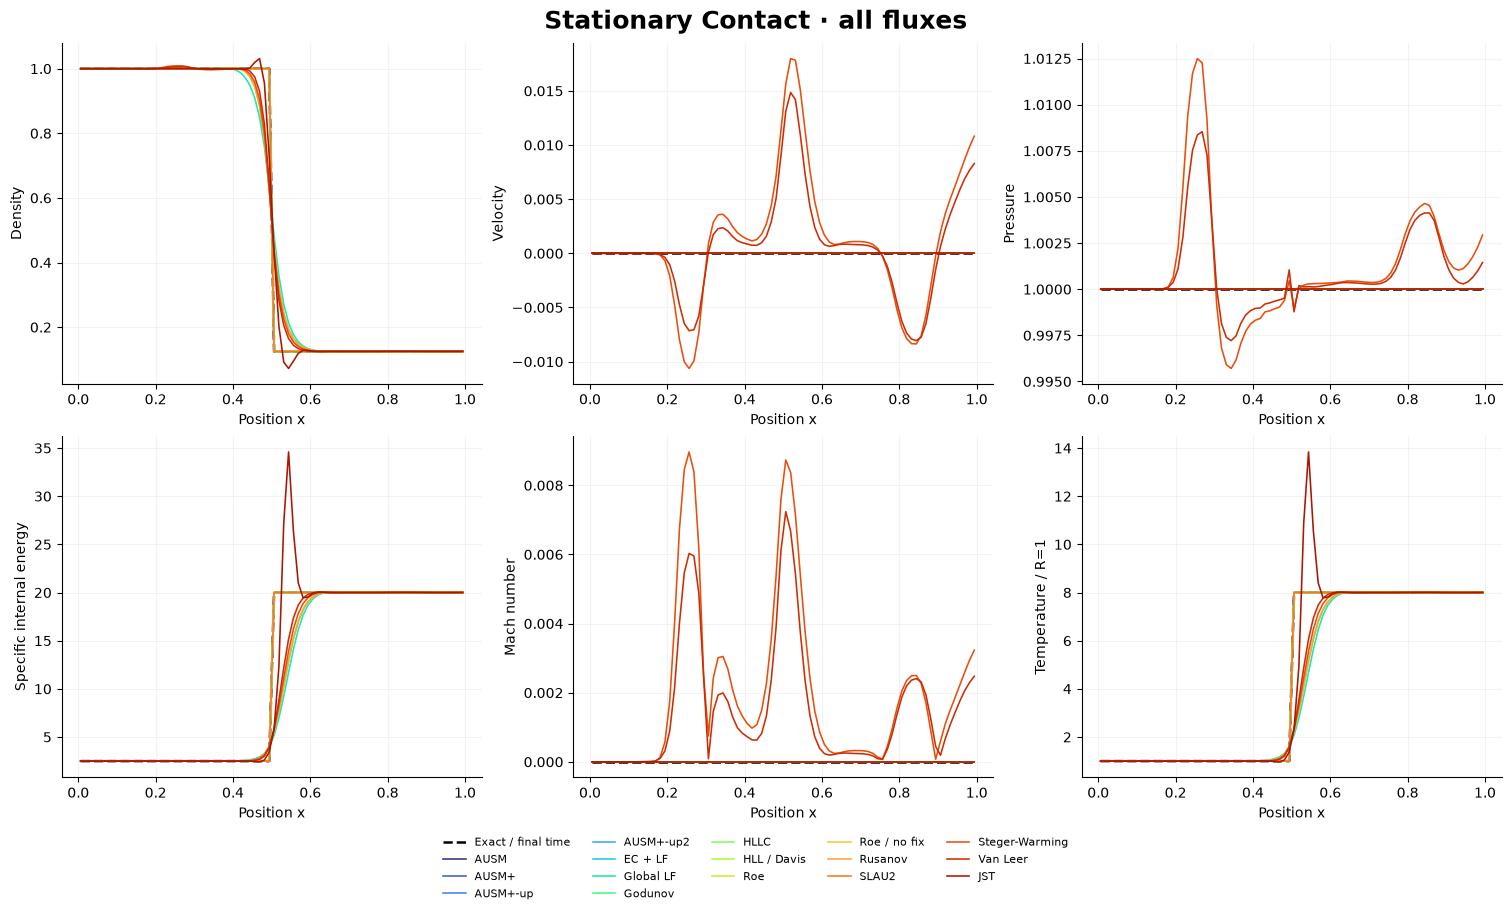

Flux,Reconstruction,Cells,Actual time,Status,Density L1,Conservation defect
HLLC,weno7-js,80,0.03129,Positivity recovery exhausted,Not eligible,8.33e-16
Roe,cweno3,80,0.0027425,Positivity recovery exhausted,Not eligible,8.19e-16
Roe / no fix,cweno3,80,0.0027425,Positivity recovery exhausted,Not eligible,8.19e-16


In [7]:
for case in ("lax","double-rarefaction","stationary-contact"):
    cases=select(study,case=case,reconstruction="cweno3")+select(study,case=case,flux="jst",reconstruction="first")
    show_table(cases)
    properties(cases,case+"-properties",case.replace("-"," ").title()+" · all fluxes")
show_table([r for r in study if not r["completed"]])


## 7. Refine the rounded shock and contact locally

Density **and** pressure jumps flag the moving waves. Refine/coarsen every eight accepted steps,
with four-cell buffers, hysteresis and a 2:1 dyadic leaf mesh. Base 80, maximum level 3 gives
the same smallest cell width as uniform 640, while retaining fewer cells away from waves.
The exact solution is used only for errors and annotations; it does not choose refinement locations.

All 15 pointwise fluxes use the same geometry-aware CWENO3 operator for these 75 comparisons.
Conservative split/merge preserves FV means, and one shared face flux/global SSPRK3 step preserves interface balance.
Raw averages are plotted as stairs; the discontinuity is not sharpened cosmetically.

The AMR path also supports first order, MUSCL/minmod, and CWENO3/5 in component or characteristic variables.
The existing uniform-grid WENO/TENO/THINC, JST and DG comparisons remain available above;
they have not been relabelled as nonuniform AMR discretizations.

[Detailed AMR report](https://github.com/Ehsan-Roohi/Ehsan-Roohi/blob/main/courses/cfd-2/modern-python/shock-tube/AMR_RESULTS.md)


Flux,Mesh,Final / mean cells,Density L1,Contact width,Shock width,Conservation defect,Status
AUSM,Uniform 160,160 / 160.0,0.004506,0.03634,0.016596,3.22e-15,Passed
AUSM,Uniform 320,320 / 320.0,0.0023622,0.022139,0.0081794,3.10e-15,Passed
AUSM,Uniform 640,640 / 640.0,0.001323,0.013417,0.0042328,2.63e-14,Passed
AUSM,Uniform 80,80 / 80.0,0.0089134,0.060594,0.033175,9.69e-16,Passed
AUSM,"AMR base 80, level 3",232 / 182.2,0.0014032,0.013223,0.0042313,1.22e-15,Passed
AUSM+,Uniform 160,160 / 160.0,0.0043639,0.036408,0.016403,3.77e-15,Passed
AUSM+,Uniform 320,320 / 320.0,0.0022911,0.022242,0.0080697,4.22e-15,Passed
AUSM+,Uniform 640,640 / 640.0,0.0012802,0.013435,0.0041051,2.42e-14,Passed
AUSM+,Uniform 80,80 / 80.0,0.008628,0.058804,0.03304,9.93e-16,Passed
AUSM+,"AMR base 80, level 3",239 / 182.5,0.001404,0.013219,0.0041048,2.17e-15,Passed


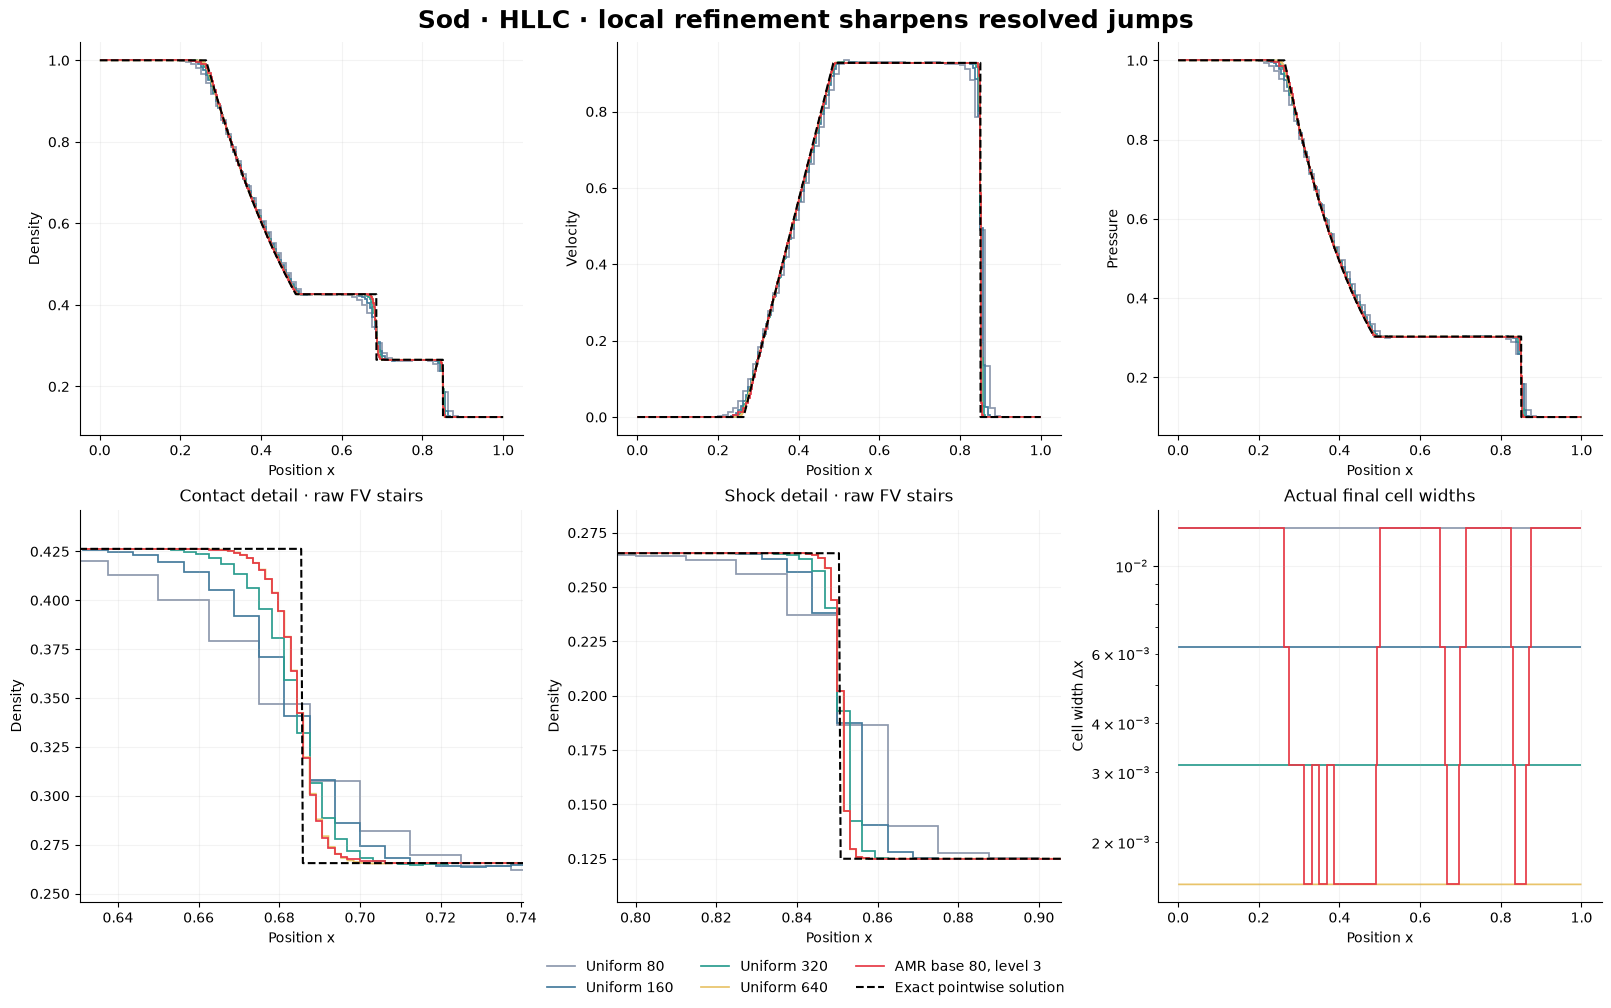

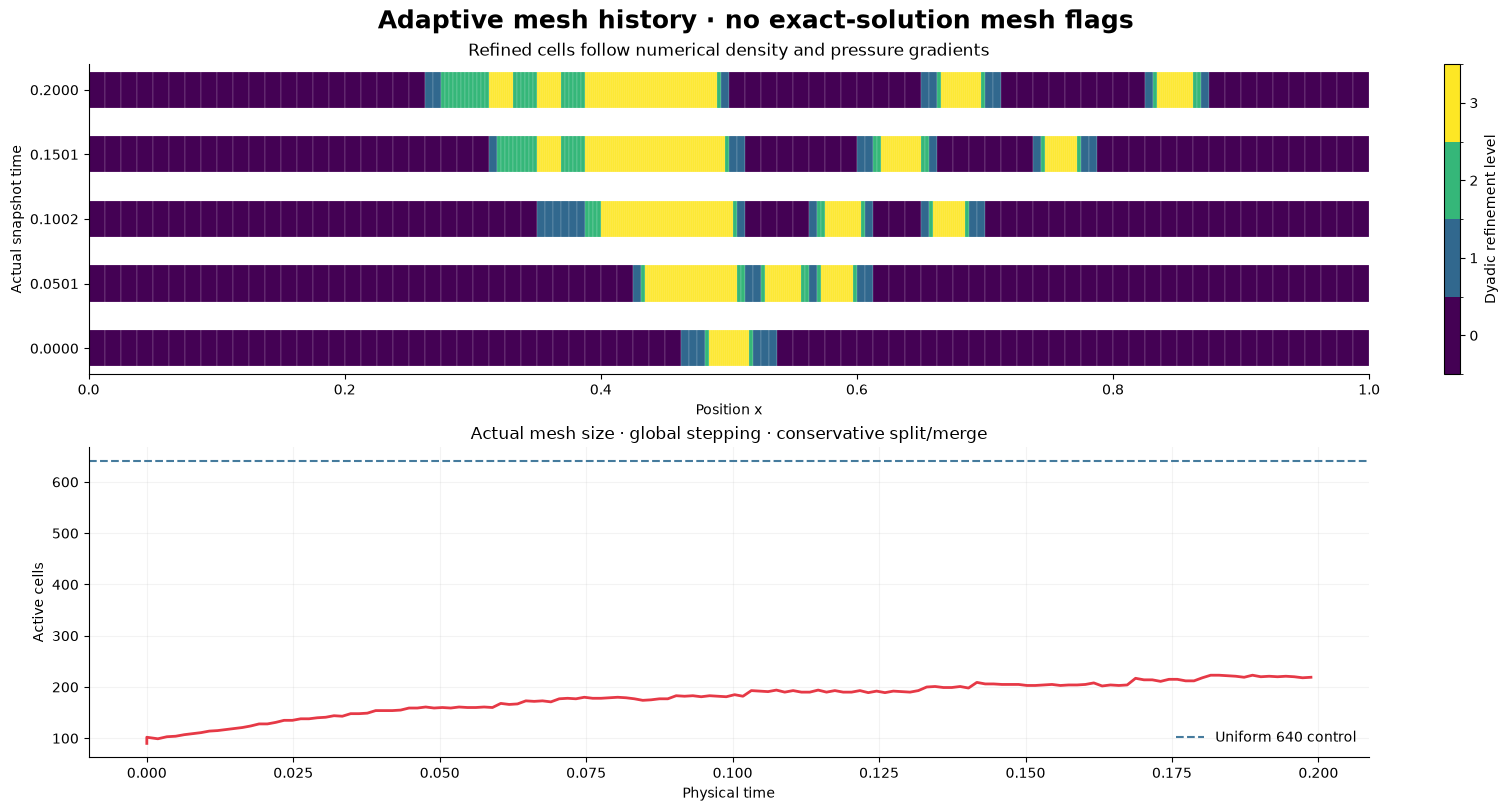

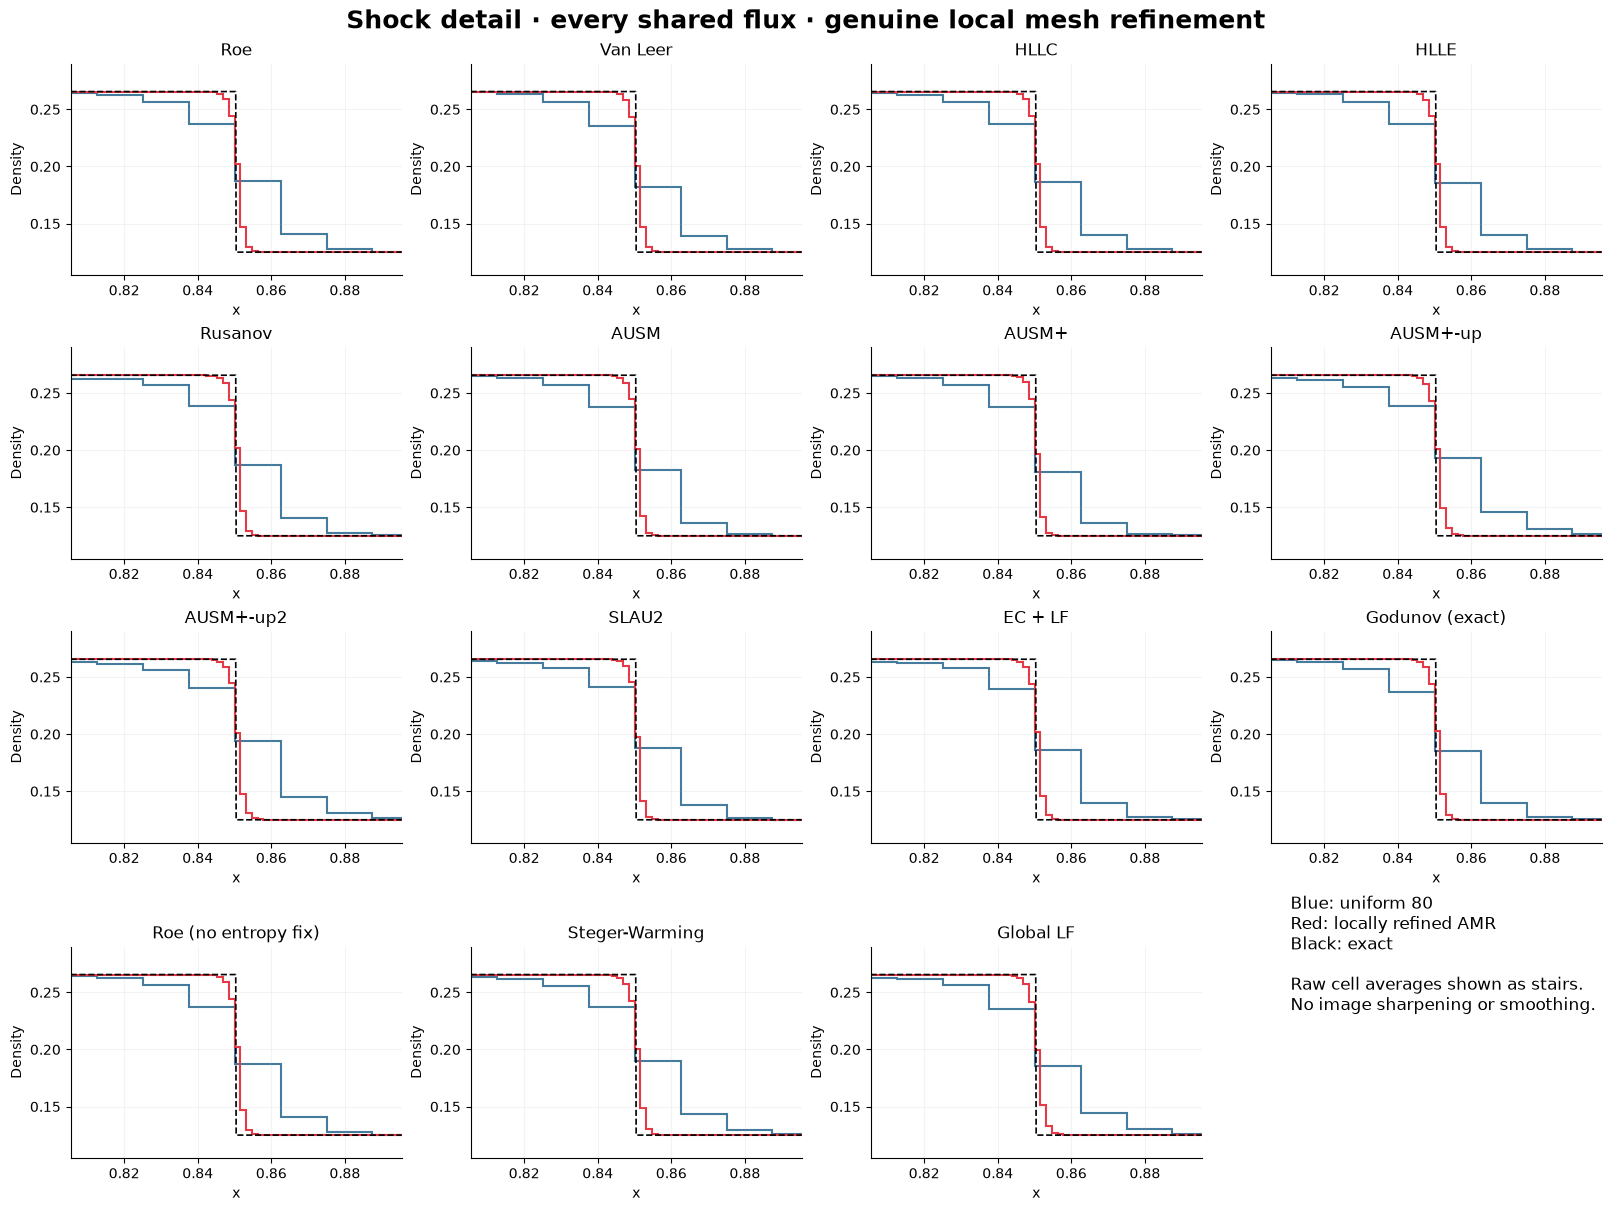

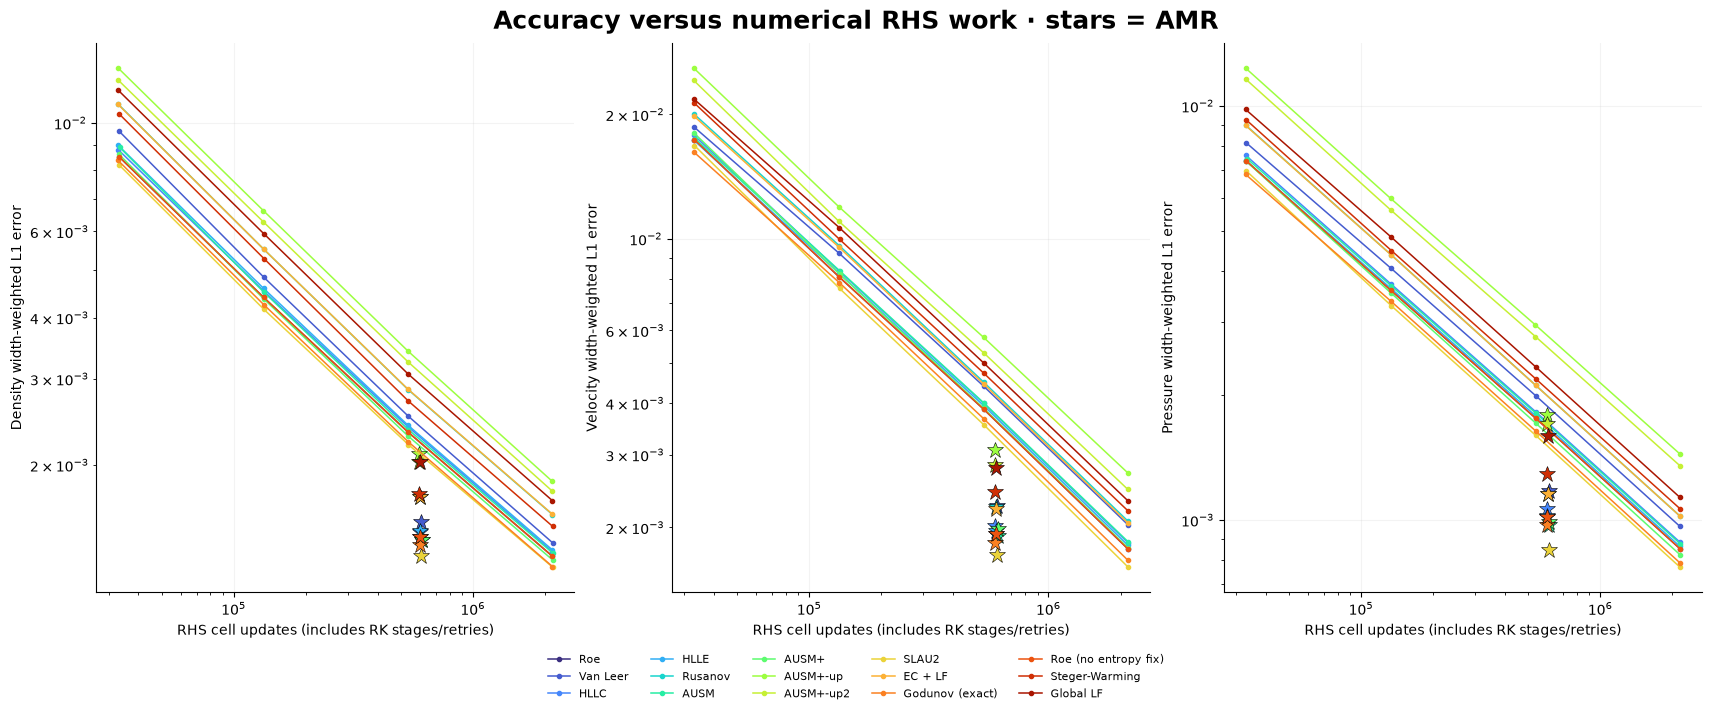

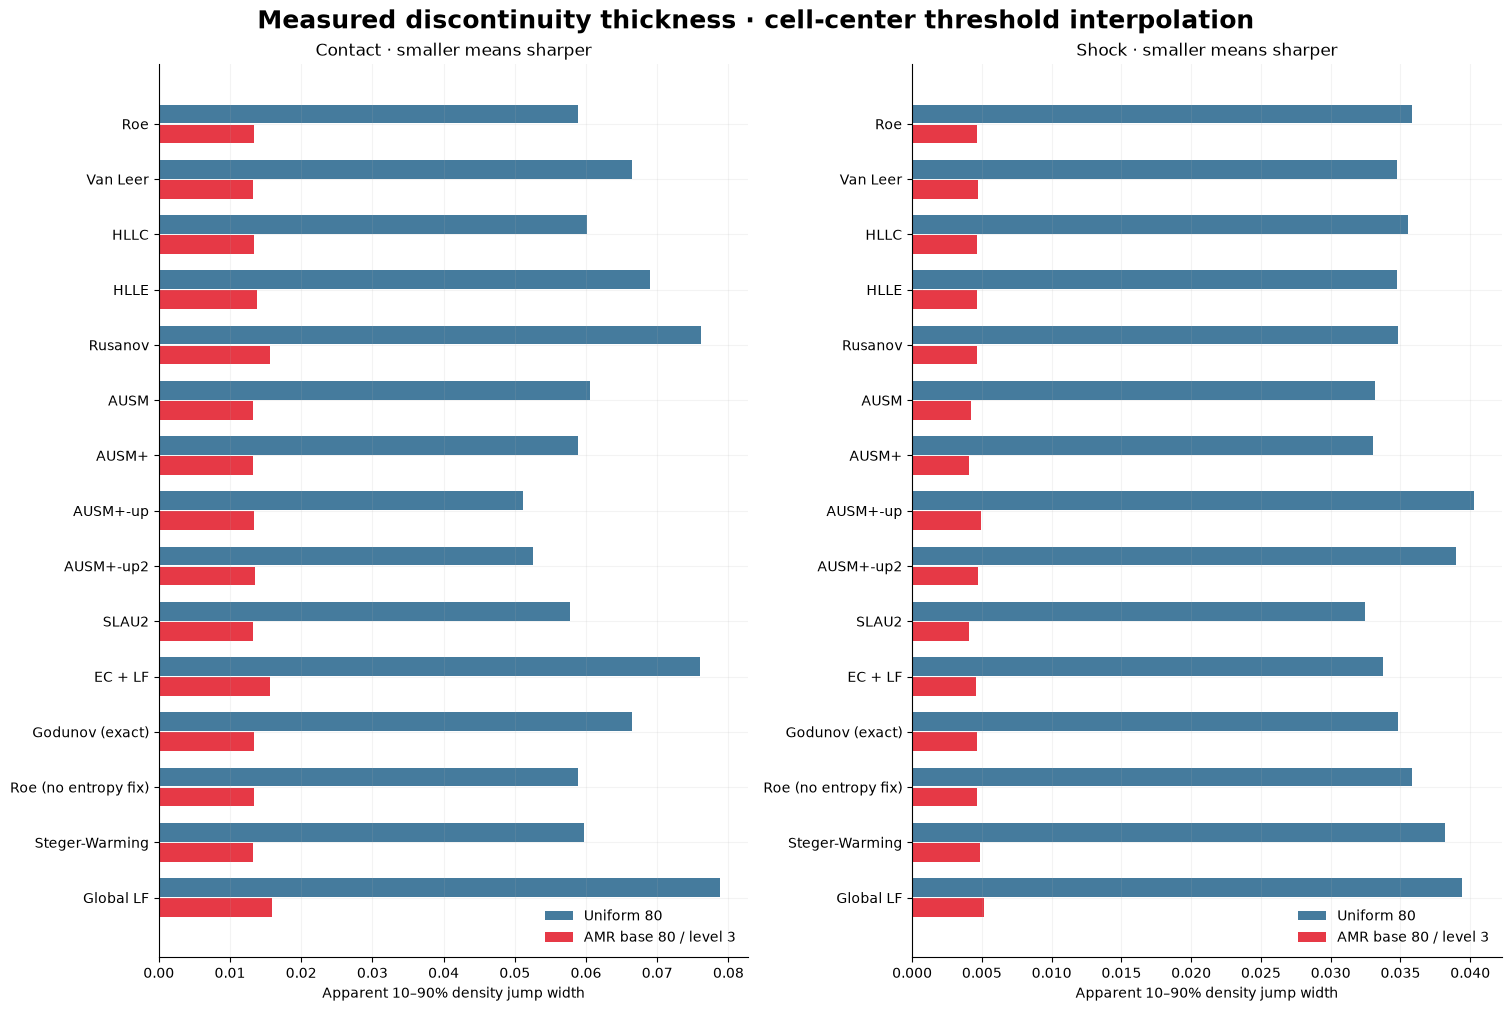

In [8]:
amr_runs=load_amr()
show_amr_table(amr_runs)
amr_profiles(amr_runs)
amr_mesh(amr_runs)
amr_cards(amr_runs)
amr_accuracy(amr_runs)
amr_widths(amr_runs)


### Compute a fresh locally refined comparison

Recorded AMR results above are from executed CPU runs. Enable this form to evolve a new adaptive mesh.
All shared pointwise fluxes are selected by default; the exact solution is never used to flag cells.


In [9]:
# @title Fresh local mesh refinement {display-mode: "form"}
Run_fresh_AMR=False # @param {type:"boolean"}
Compare_all_AMR_fluxes=True # @param {type:"boolean"}
AMR_base_cells=80 # @param {type:"integer"}
AMR_max_level=3 # @param [0,1,2,3,4]
AMR_flux="hllc" # @param ["roe","vanleer","hllc","hlle","rusanov","ausm","ausm-plus","ausm-up","ausm-up2","slau2","ec-lf","godunov","roe-nc","steger-warming","global-lf"]
AMR_reconstruction="cweno3" # @param ["first","muscl","minmod","cweno3","cweno5","cweno3-char","cweno5-char"]
if Run_fresh_AMR:
    new_amr=[]
    for method in list(FLUXES) if Compare_all_AMR_fluxes else [AMR_flux]:
        try:
            new_amr.append(run_amr(method,AMR_reconstruction,AMR_base_cells,AMR_max_level,output_dir=WORK/"fresh-amr-results"))
        except (ValueError,RuntimeError,FloatingPointError) as error:print(method,type(error).__name__,str(error))
    show_amr_table(new_amr)
    if new_amr:properties(new_amr,"fresh-amr-properties","Fresh Sod · conservative local refinement")
else:print("Recorded AMR comparisons are displayed above. Enable this form for a new adaptive calculation.")


Recorded AMR comparisons are displayed above. Enable this form for a new adaptive calculation.


## 8. Compute a fresh uniform-grid comparison

Recorded outputs above come from executed local CPU runs. Enable the optional comparison to recompute in this session.
The default fresh selection compares every shared flux; use the full matrix option to recompute all 300 combinations.
JST is added separately. Failed runs remain in the table and do not abort the other methods.


In [10]:
# @title Fresh shock-tube comparison {display-mode: "form"}
Run_fresh_comparison=False # @param {type:"boolean"}
Run_full_matrix=False # @param {type:"boolean"}
Compare_all_fluxes=True # @param {type:"boolean"}
Case="sod" # @param ["sod","lax","double-rarefaction","stationary-contact"]
Cells=80 # @param {type:"integer"}
Flux="hllc" # @param ["roe","vanleer","hllc","hlle","rusanov","ausm","ausm-plus","ausm-up","ausm-up2","slau2","ec-lf","godunov","roe-nc","steger-warming","global-lf","jst"]
Reconstruction="cweno3" # @param ["first","muscl","cweno3","cweno5","cweno3-char","cweno5-char","muscl-minmod","muscl-vanleer","muscl-superbee","muscl-vanalbada","eno2","weno3-js","weno3-z","weno5-js","weno5-z","weno7-js","teno3","teno5","teno7","muscl-thinc-bvd"]
DG_degree=-1 # @param [-1,0,1,2]
fresh=[]
if Run_fresh_comparison:
    methods=list(FLUXES) if Compare_all_fluxes or Run_full_matrix else [Flux]
    reconstructions=RECONSTRUCTIONS if Run_full_matrix and DG_degree<0 else [Reconstruction]
    for method in methods:
        for rec in reconstructions:
            try:
                fresh.append(run_case(method,"first" if method=="jst" else rec,Cells,Case,DG_degree,output_dir=WORK/"fresh-results"))
            except (ValueError,RuntimeError,FloatingPointError) as error:
                print(f"{method} / {rec}: {type(error).__name__}: {error}")
    if Compare_all_fluxes and DG_degree<0:
        fresh.append(run_case("jst","first",Cells,Case,-1,output_dir=WORK/"fresh-results"))
    show_table(fresh,collapsible=Run_full_matrix)
    if fresh and not Run_full_matrix:properties(fresh,"fresh-properties","Fresh session · computed shock-tube properties")
else:print("Recorded comparisons are displayed above. Enable fresh execution to recompute.")


Recorded comparisons are displayed above. Enable fresh execution to recompute.


## Verification and sources

[Algorithm audit](https://github.com/Ehsan-Roohi/Ehsan-Roohi/blob/main/courses/cfd-2/modern-python/conical/ADDITIONAL_METHODS.md) explains FV moments, smooth-order measurements, scope and source attribution.
The Godunov sampler is cross-checked against the independent original Sod solution and a true vacuum sample.
Conservation includes the SSPRK-weighted boundary flux budget. Mesh errors compare exact conserved cell averages.
Reference quadrature changes are stored in every run record.

References: [NASA AUSM shock tube](https://github.com/nasa/shocktube),
[Python comparison framework](https://github.com/fhermet/euler-1d-solver),
[CAELUM](https://github.com/navasmontilla/CAELUM), [Quail](https://github.com/IhmeGroup/quail),
[BVD](https://arxiv.org/abs/1602.00814).
